# Camera Calibration with OpenCV
This notebook demonstrates the process of calibrating a camera using images of a chessboard pattern. It covers:
- Loading calibration images
- Detecting and refining chessboard corners
- Preparing object and image points
- Running camera calibration
- Visualizing results and undistorting images


# checkboard downloads
- https://markhedleyjones.com/projects/calibration-checkerboard-collection


In [1]:
# Import required libraries for camera calibration and visualization
import cv2, json  # OpenCV for computer vision, json for data handling
import numpy as np  # Numerical operations
import matplotlib.pyplot as plt  # Plotting images
np.set_printoptions(precision=2, suppress=True)  # Format numpy output for readability

/home/ngoc/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


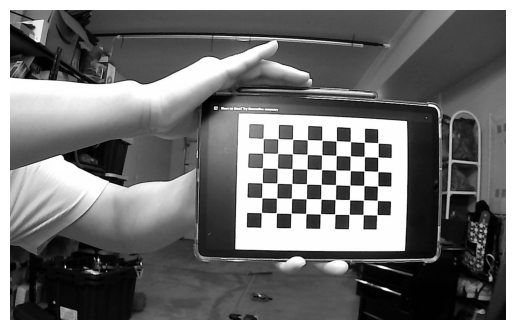

In [2]:
# Load the first calibration image from the left camera 

img = cv2.imread(f"data/elp210/images_calib/left/{0:06d}.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))            #giúp đảo ngược hệ màu từ BGR sang RGB. Nếu không có bước này, bức ảnh hiện lên sẽ bị sai màu (ví dụ: quả táo màu đỏ sẽ biến thành màu xanh dương).
plt.axis('off')
plt.show()

# Get image dimensions (height and width)

h, w = img.shape[:2] #chỉ lấy 2 giá trị đầu tiên (chiều cao và chiều rộng), bỏ qua số lượng kênh màu (số 3).


In [3]:
# Define the shape of the chessboard (number of inner corners per row and column)
board_shape = (9, 6)  # 9 columns and 6 rows of inner corners

# Size of one checker square in millimeters
checker_size = 14  # in mm

# Termination criteria for corner refinement: 
## cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER: Stop either when accuracy is reached or max iterations 
## 30: Maximum number of iterations_ Dừng lại nếu đã thực hiện lặp lại (iteration) 30 lần.
## 0.001: Desired accuracy (epsilon) _ Dừng lại nếu mức độ xê dịch giữa 2 lần tính toán liên tiếp nhỏ hơn 0.001 (đã đạt độ chính xác mong muốn).
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points for the chessboard corners in 3D space (z=0)
## Create a grid of points for the chessboard corners

objp = np.zeros((board_shape[1]*board_shape[0], 3), np.float32) # (54,3) . . . 
#Tạo một ma trận chứa 54 điểm (9 cột x 6 hàng). Mỗi điểm có 3 giá trị tương ứng với tọa độ không gian 3 chiều (x, y, z). Ban đầu tất cả bằng 0. (Vì bàn cờ là một mặt phẳng, nên trục z luôn bằng 0).

objp[:, :2] =  np.mgrid[0:board_shape[0], 0: board_shape[1]].T.reshape(-1, 2)
#Lệnh này tự động điền tọa độ (x, y) theo dạng lưới (grid) vào ma trận trên. Nó sẽ tạo ra các tọa độ nối tiếp nhau: (0,0), (1,0), (2,0) ... (8,5).
#Lay tat ca cac hang nhung chi lay cot 2 cot dau tien

objp *= checker_size  # scale to mm
# Nhân toàn bộ tọa độ lưới vừa tạo với kích thước thật của ô vuông (14mm). Kết quả cuối cùng là tọa độ thật sự theo milimét

# Arrays to store object points (3D) and image points (2D) from all images
objpoints = []  # 3D points in board coords 
#Một danh sách trống. Nó sẽ dùng để chứa nhiều bản sao của ma trận 3D lý tưởng objp ở trên (mỗi bức ảnh hiệu chuẩn sẽ đi kèm một bản sao này).

imgpoints = []  # 2D points in image plane
#Một danh sách trống. Sau này, khi OpenCV quét từng bức ảnh và tìm ra tọa độ 2D của các góc bàn cờ trên ảnh,

# Image shape (width, height)
img_shape = (w, h)

In [6]:
print(np.zeros((board_shape[1]*board_shape[0], 3), np.float32))

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [7]:
print(np.mgrid[0:board_shape[0]    ,  0: board_shape[1]].T.reshape(-1, 2))

[[0 0]
 [1 0]
 [2 0]
 [3 0]
 [4 0]
 [5 0]
 [6 0]
 [7 0]
 [8 0]
 [0 1]
 [1 1]
 [2 1]
 [3 1]
 [4 1]
 [5 1]
 [6 1]
 [7 1]
 [8 1]
 [0 2]
 [1 2]
 [2 2]
 [3 2]
 [4 2]
 [5 2]
 [6 2]
 [7 2]
 [8 2]
 [0 3]
 [1 3]
 [2 3]
 [3 3]
 [4 3]
 [5 3]
 [6 3]
 [7 3]
 [8 3]
 [0 4]
 [1 4]
 [2 4]
 [3 4]
 [4 4]
 [5 4]
 [6 4]
 [7 4]
 [8 4]
 [0 5]
 [1 5]
 [2 5]
 [3 5]
 [4 5]
 [5 5]
 [6 5]
 [7 5]
 [8 5]]


# Collecting Calibration Points
We loop through multiple calibration images, detect and refine chessboard corners, and store the corresponding 3D object points and 2D image

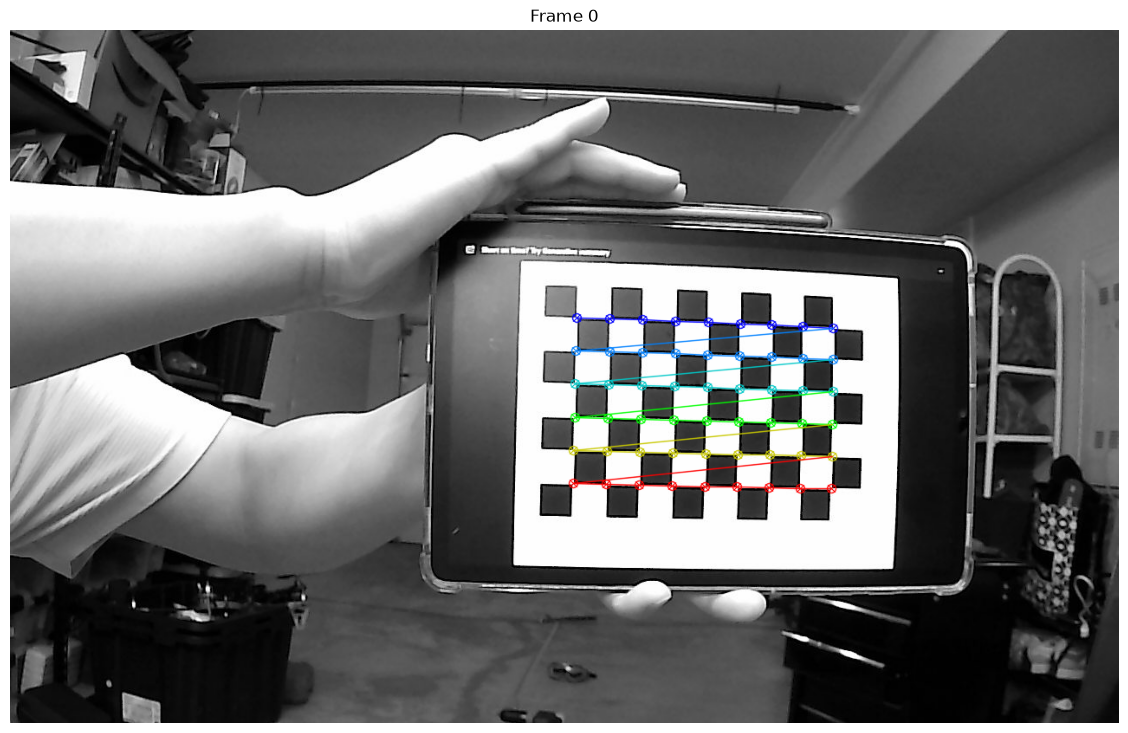

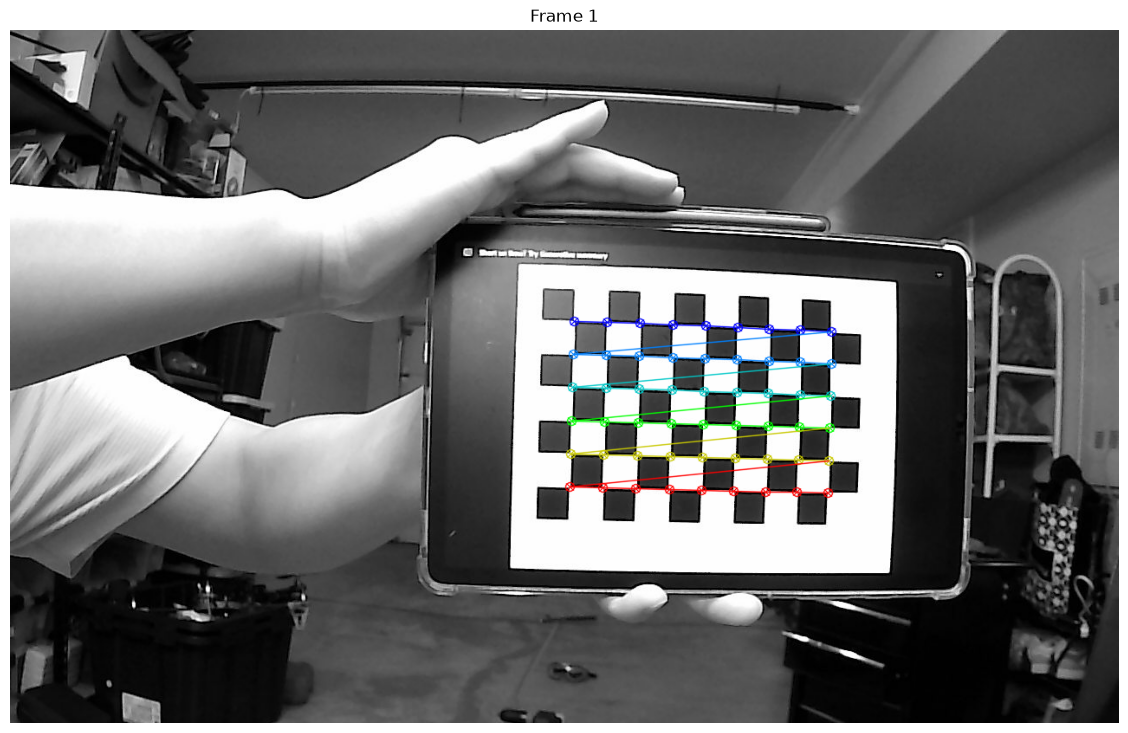

In [4]:
  # Loop through a small set of calibration images to visualize corner detection
frame_ids = list(range(0, 2, 1))  # Adjust as needed for more images
for i in frame_ids:
    # Load the current image
    frame = cv2.imread(f"data/elp210/images_calib/left/{i:06d}.jpg")
    
    # Find chessboard corners in the image
    ret, corners = cv2.findChessboardCorners(frame, board_shape, flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
    
    # Refine corner locations to subpixel accuracy
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    corners_ref = cv2.cornerSubPix(gray_frame, corners, (11, 11), (-1, -1), criteria)
    
    # Draw the refined corners on the image for visualization 
    frame = cv2.drawChessboardCorners(frame, board_shape, corners_ref, ret)
    
    # Show the result
    plt.figure(figsize=(16, 9))
    plt.imshow(frame)
    plt.title(f"Frame {i}")
    plt.axis('off')
    plt.show()

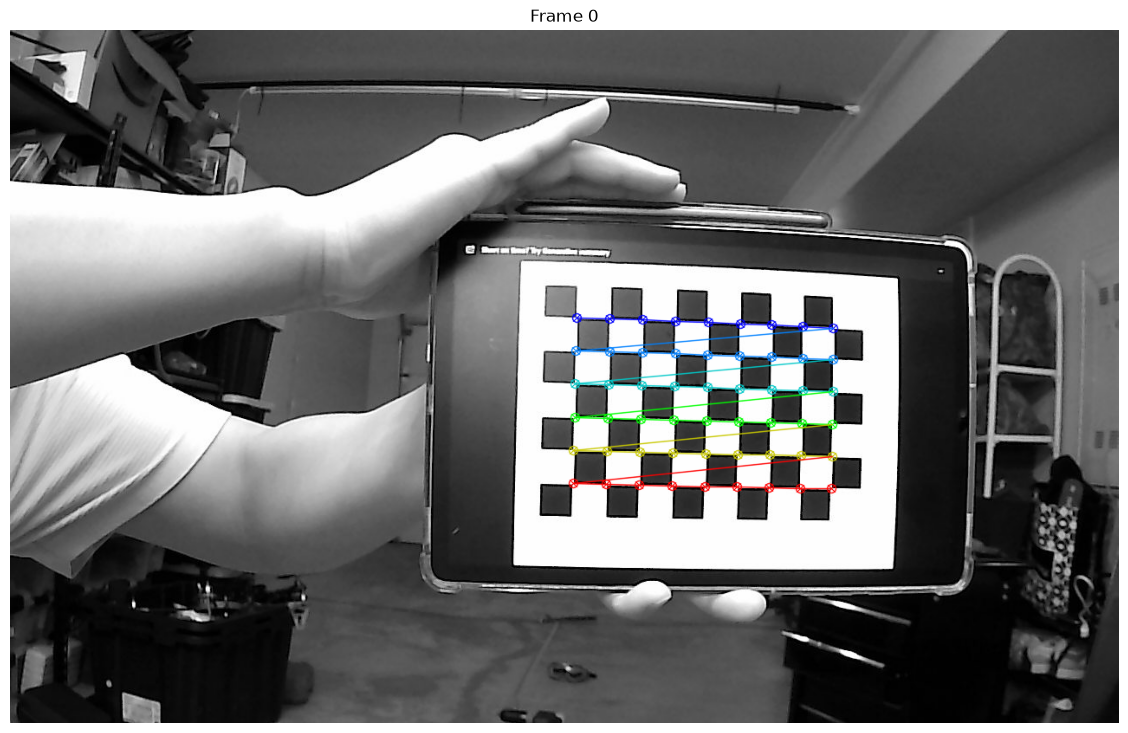

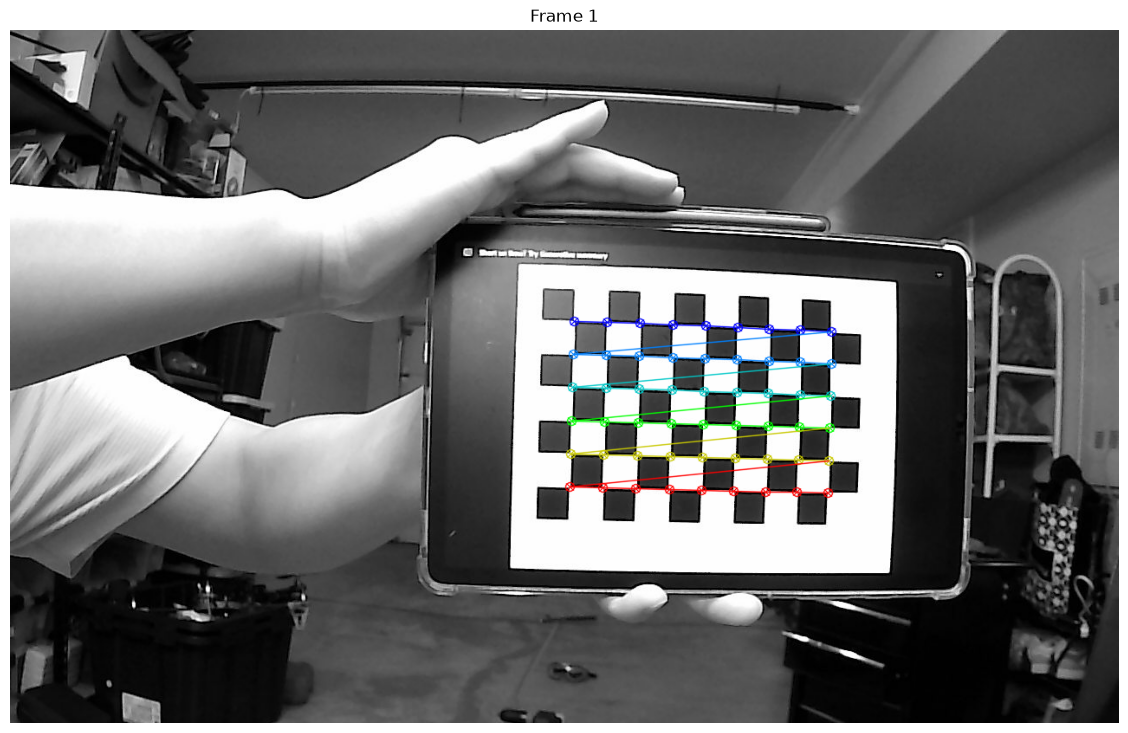

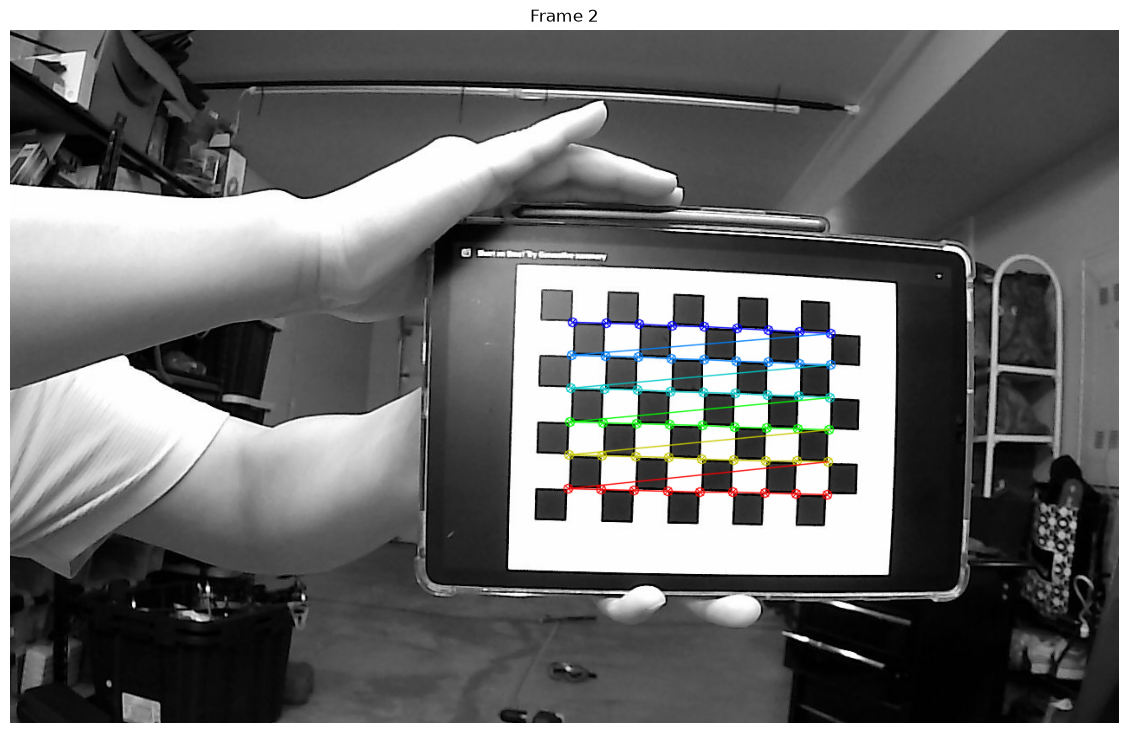

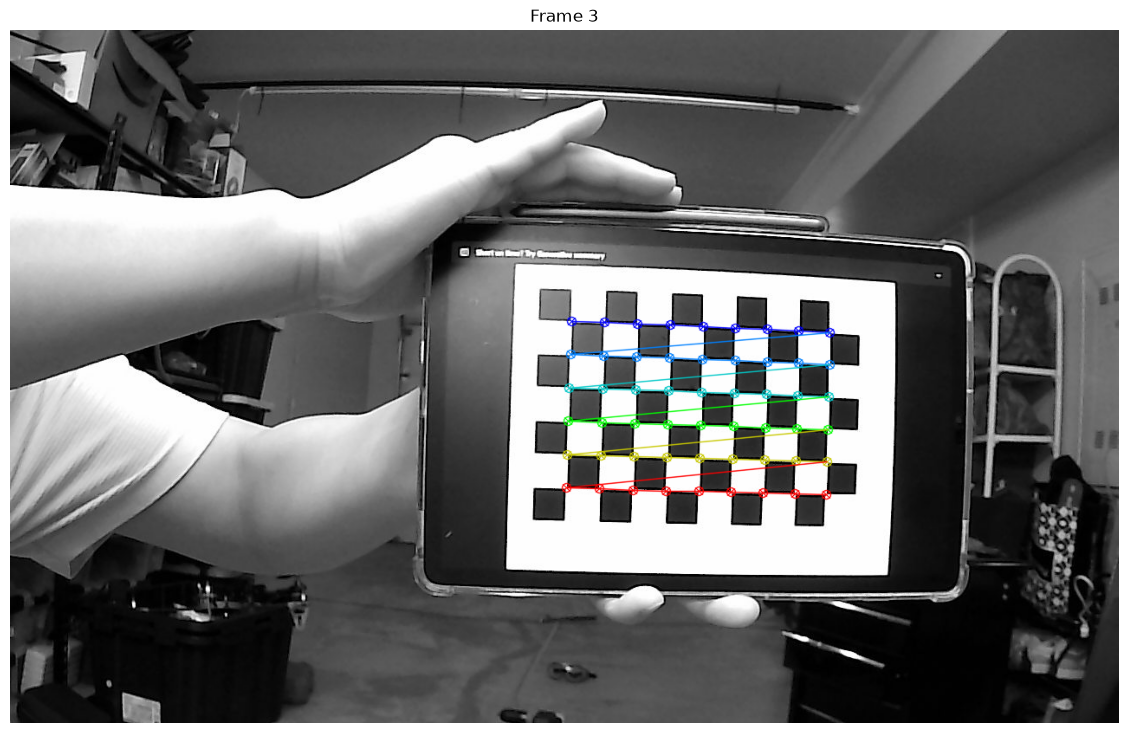

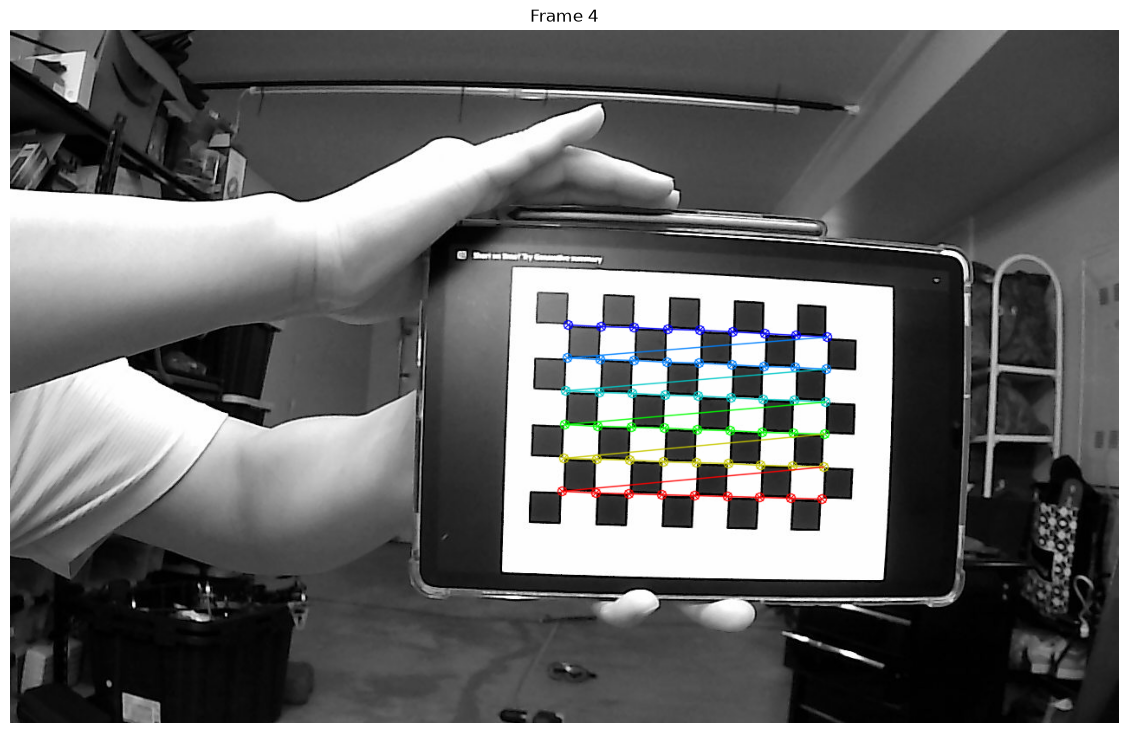

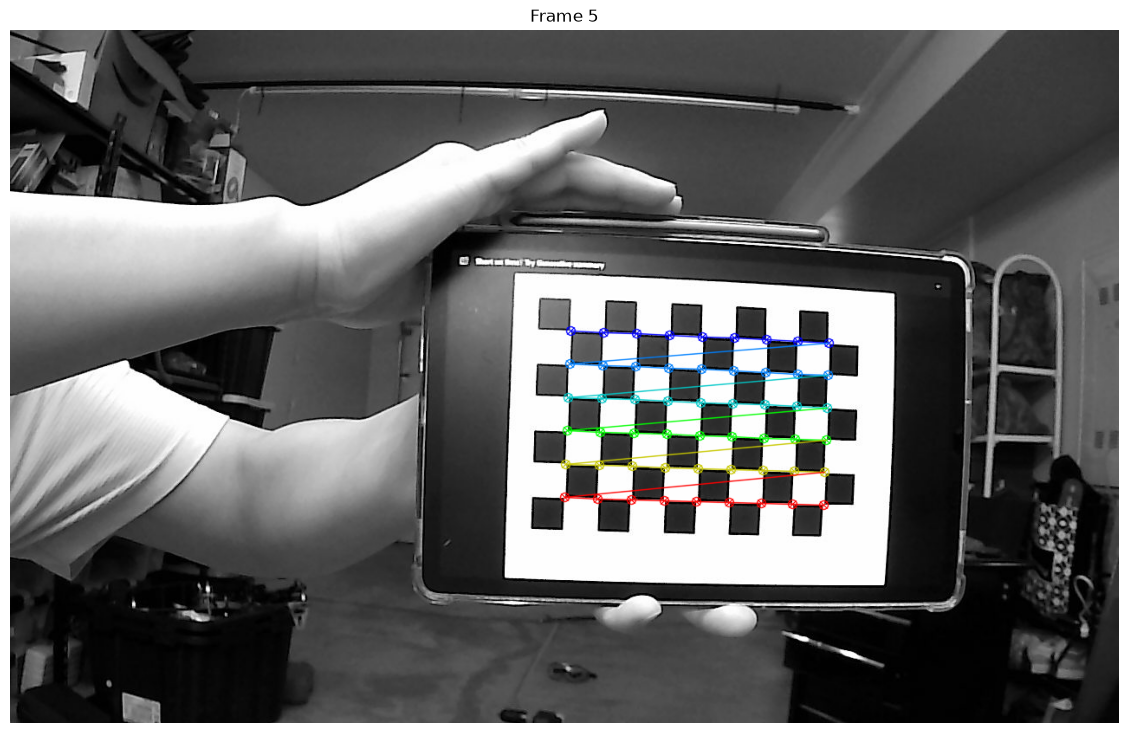

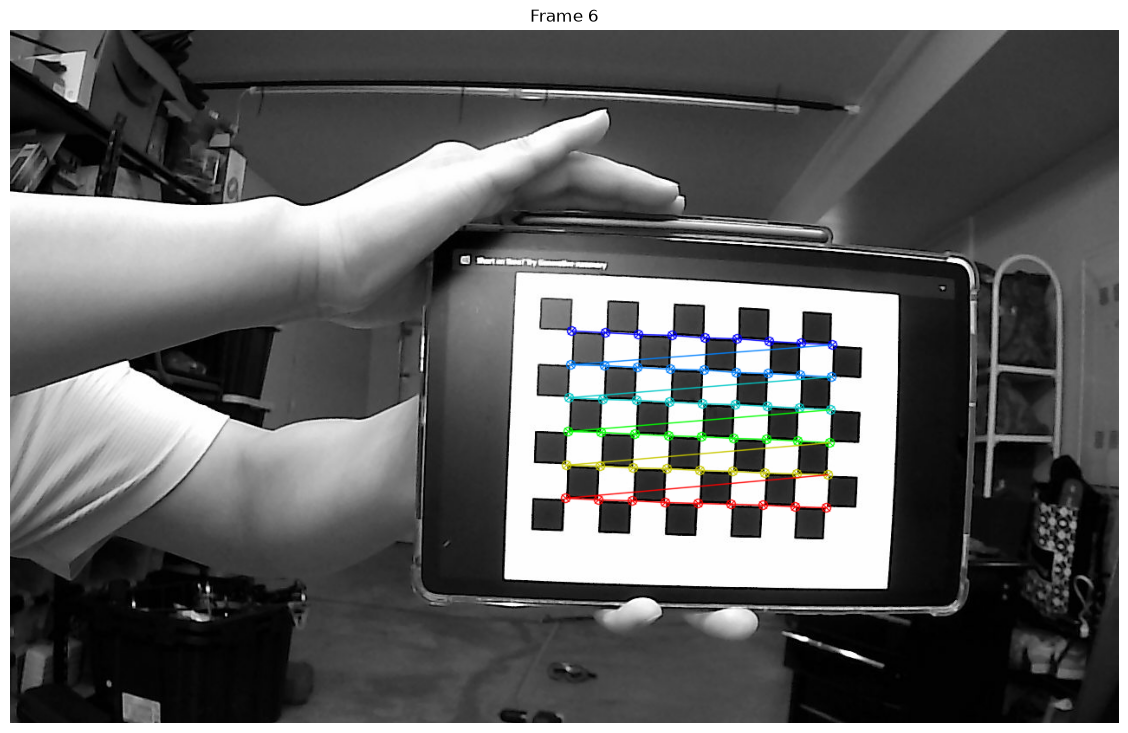

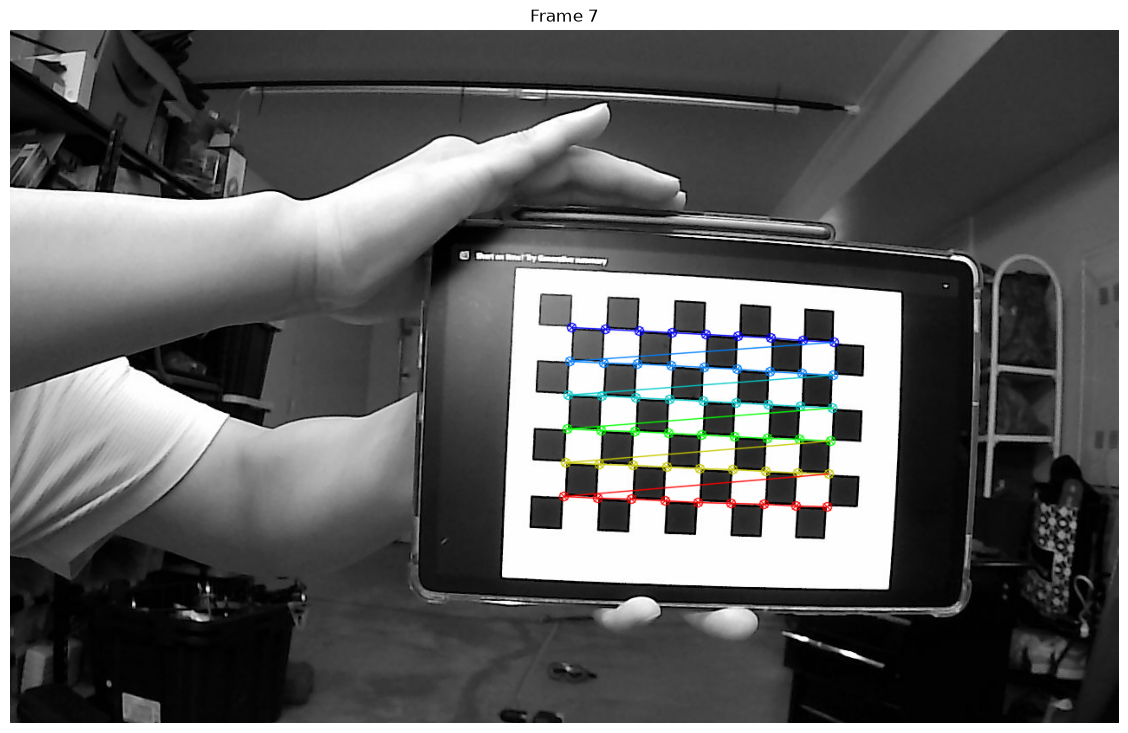

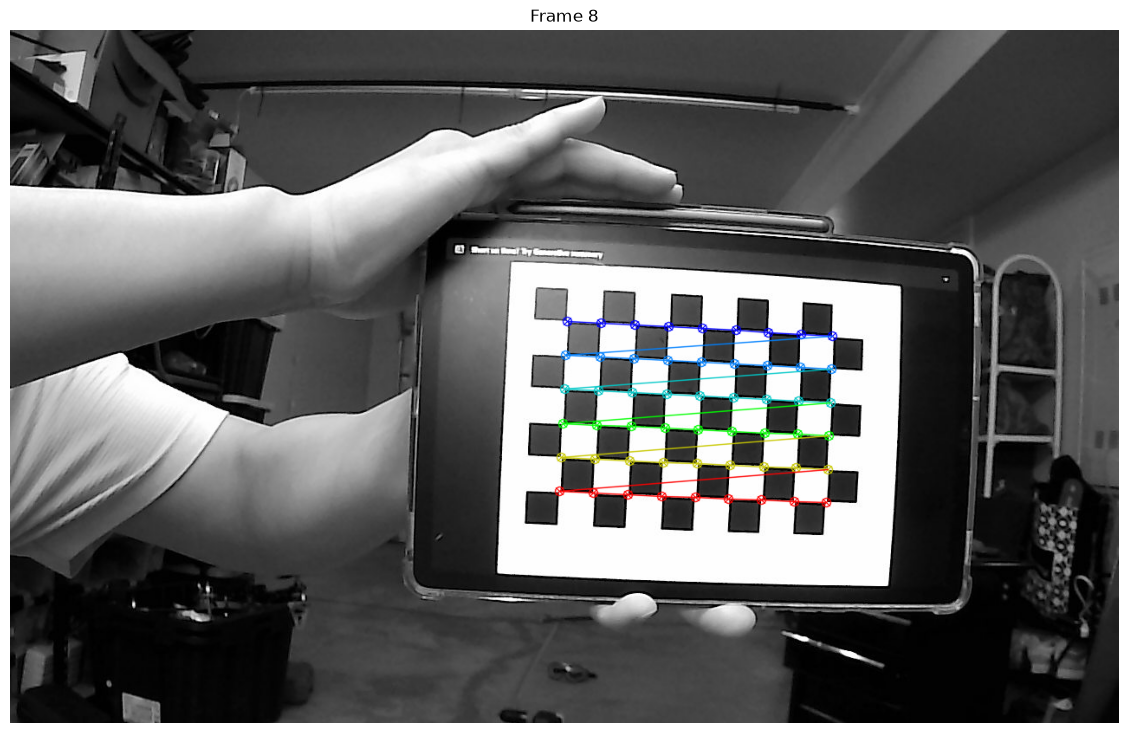

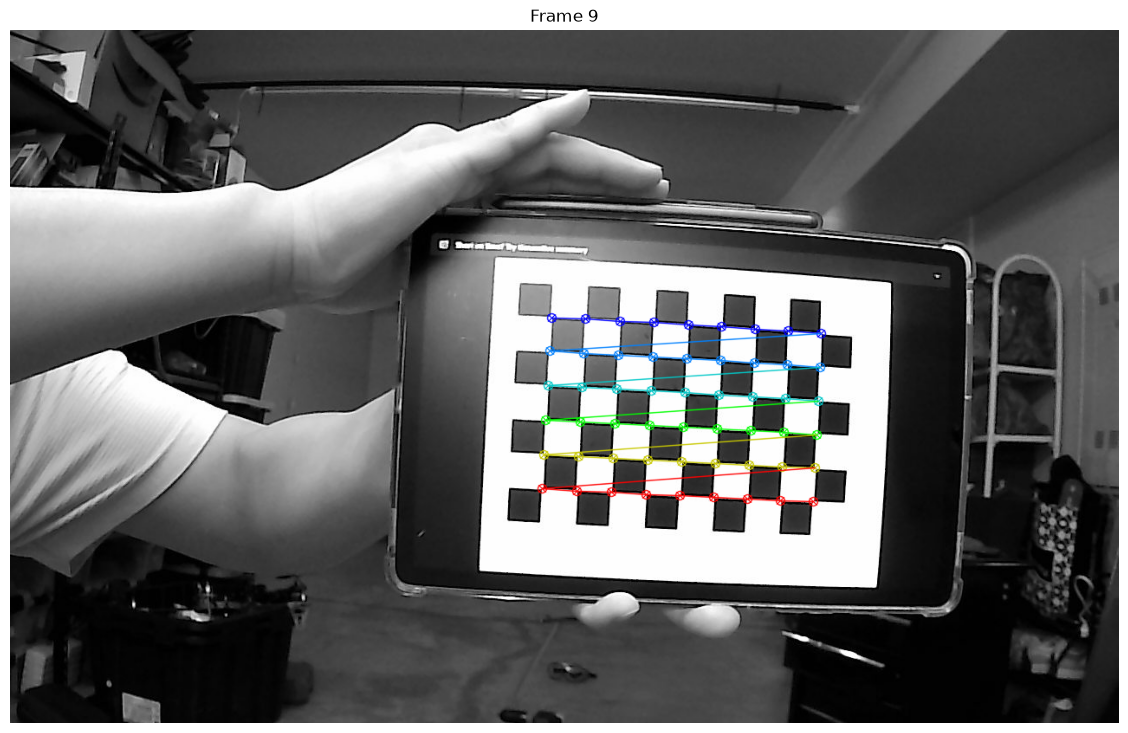

In [5]:
# Loop through a small set of calibration images to visualize corner detection
frame_ids = list(range(0, 10, 1))  # Adjust as needed for more images
for i in frame_ids:
    # Load the current image
    frame = cv2.imread(f"data/elp210/images_calib/left/{i:06d}.jpg")
    
    # Find chessboard corners in the image
    ret, corners = cv2.findChessboardCorners(frame, board_shape, flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)
    
    # Refine corner locations to subpixel accuracy
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    corners_ref = cv2.cornerSubPix(gray_frame, corners, (11, 11), (-1, -1), criteria)
    
    # Draw the refined corners on the image for visualization 
    frame = cv2.drawChessboardCorners(frame, board_shape, corners_ref, ret)


    # Store the object points and image points for calibration
    objpoints.append(objp.copy())
    imgpoints.append(corners_ref)
    
    #Show the result
    plt.figure(figsize=(16, 9))
    plt.imshow(frame)
    plt.title(f"Frame {i}")
    plt.axis('off')
    plt.show() 

## Camera Calibration
Using the collected points, we estimate the camera's intrinsic matrix and distortion coefficients. The RMS reprojection error indicates the calibration quality.

Using the collected points, we estimate the camera's intrinsic matrix and distortion coefficients. The RMS reprojection error indicates the calibration

In [6]:
# Set calibration flags
flags = cv2.CALIB_FIX_K3 | cv2.CALIB_USE_INTRINSIC_GUESS  # Fix k3 distortion, use initial guess for intrinsics

# Initial camera matrix setup (intrinsic parameters)
initial_fx = 1000.0  # Initial horizontal focal length
initial_fy = 1000.0  # Initial vertical focal length (square pixels)
image_width = 1280
image_height = 800
initial_cx = image_width / 2  # Principal point x
initial_cy = image_height / 2  # Principal point y
initial_camera_matrix = np.array([[initial_fx, 0, initial_cx],
                                [0, initial_fy, initial_cy],
                                [0, 0, 1]], dtype=np.float32)

# Run camera calibration using collected object and image points
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, img_shape, 
        cameraMatrix=initial_camera_matrix, distCoeffs=None,
        flags=flags, 
        criteria=criteria
    )

# Print calibration results
print("\n=== Calibration Results (LEFT) ===")
print(f"RMS reprojection error: {ret:.4f}")
print("K (intrinsics):\n", mtx)
print("dist (k1 k2 p1 p2 k3):\n", dist.ravel())


=== Calibration Results (LEFT) ===
RMS reprojection error: 0.2017
K (intrinsics):
 [[999.34   0.   639.73]
 [  0.   997.83 400.06]
 [  0.     0.     1.  ]]
dist (k1 k2 p1 p2 k3):
 [-0.28 -0.02  0.02  0.    0.  ]


# Undistoring Images
After calibration, we can remove lens distortion from images using the computed camera parameters. This improves measurement accuracy and visual quality

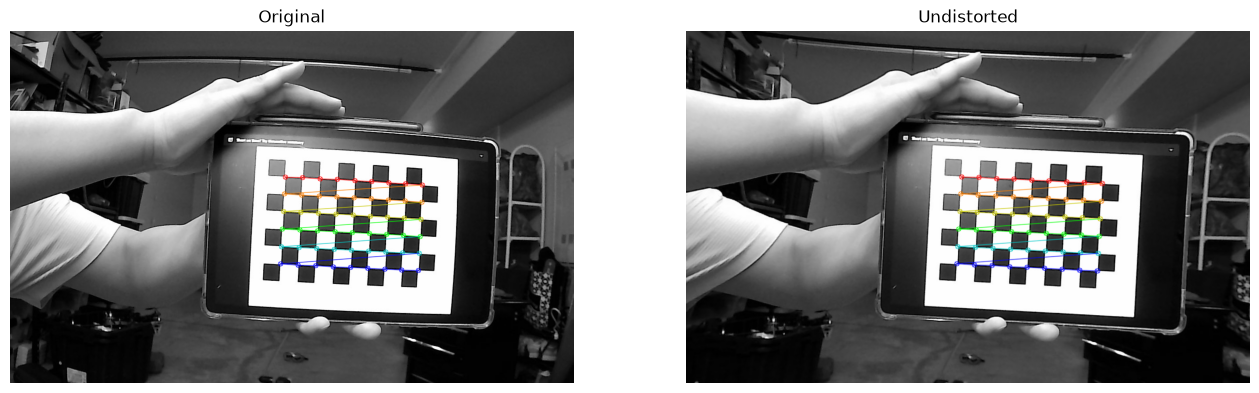

In [7]:
# Undistort the image using the computed camera matrix and distortion coefficients
undistorted = cv2.undistort(frame, mtx, dist)

# Visualize the original and undistorted images side by side
plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.title("Original")
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.axis('off')
plt.title("Undistorted")
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.show()

#### viet 1 chuong doc webcam, sau do thuc hien chup lai buc anh chua tam chessboard, moi lan nhan 's' thuc hien luu anh vaof disk (20 tam)